<a href="https://colab.research.google.com/github/Markeloen/Kaggle-Shoplifting-Dataset---obileNetV2-CNN-LSTM-Model/blob/master/notebookd98acb33ba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shoplifting Detection using Video Analysis

This notebook demonstrates a deep learning approach to detect shoplifting events from video data. It utilizes a MobileNetV2-based CNN combined with an LSTM layer to classify video sequences as either 'normal' or 'shoplifting'.

## Table of Contents
1.  [Introduction](#introduction)
2.  [Dataset](#dataset)
3.  [Data Preprocessing](#data-preprocessing)
4.  [Model Architecture](#model-architecture)
5.  [Training and Evaluation](#training-and-evaluation)
6.  [Results and Analysis](#results-and-analysis)

## 1. Introduction
This project aims to build a video classification model capable of identifying shoplifting incidents. The approach involves extracting frames from video clips, processing them using a pre-trained Convolutional Neural Network (CNN) (MobileNetV2), and then feeding the features into a Long Short-Term Memory (LSTM) network to capture temporal dependencies.

## 2. Dataset
The dataset used is the 'Shoplifting Video Dataset' by 'kipshidze' from Kaggle. It consists of video clips categorized into:
*   `normal`: Videos depicting typical store activities.
*   `shoplifting`: Videos showing shoplifting events.

**Dataset Details:**
*   Total Videos: 182
*   Normal Videos: 90
*   Shoplifting Videos: 92

## 3. Data Preprocessing
The preprocessing steps include:
*   **Video Loading:** A custom `load_video` function extracts a fixed number of frames (16 frames) from each video.
*   **Resizing:** Frames are resized to 112x112 pixels.
*   **Normalization:** Pixel values are normalized to the range [0, 1].
*   **Splitting:** The dataset is split into training (80%) and testing (20%) sets, ensuring stratification to maintain class distribution.
*   **MobileNetV2 Preprocessing:** Input frames are scaled to [-1, 1] as required by the MobileNetV2 model.

## 4. Model Architecture
The model is a hybrid CNN-LSTM architecture:
*   **Base CNN:** A pre-trained `MobileNetV2` model (without the top classification layer) is used as a feature extractor. It processes each frame independently using a `TimeDistributed` layer.
*   **Temporal Layer:** An `LSTM` layer processes the sequence of features extracted by the CNN, capturing temporal patterns.
*   **Dense Layers:** Fully connected layers with ReLU activation and Dropout for regularization.
*   **Output Layer:** A single `Dense` layer with sigmoid activation for binary classification (normal vs. shoplifting).

**Compilation Details:**
*   **Optimizer:** Adam with a learning rate of 1e-4.
*   **Loss Function:** Binary Crossentropy.
*   **Metrics:** Accuracy, Precision, and Recall.

## 5. Training and Evaluation
The model is trained for 15 epochs with a batch size of 4. A validation split of 20% is used during training.

**Training History (`history_transfer` details):**
*   Epochs: 15
*   Batch Size: 4
*   Metrics monitored: Accuracy, Loss, Precision, Recall, and their validation counterparts.

After training, the model's performance is evaluated on the test set.

## 6. Results and Analysis
### Evaluation Metrics on Test Set:
*   **Test Loss:** 0.4148
*   **Test Accuracy:** 0.8378
*   **Test Precision:** 0.8421
*   **Test Recall:** 0.8421

### Confusion Matrix:
```
[[15  3]
 [ 3 16]]
```
*   **True Negatives (Normal correctly classified):** 15
*   **False Positives (Normal misclassified as Shoplifting):** 3
*   **False Negatives (Shoplifting misclassified as Normal):** 3
*   **True Positives (Shoplifting correctly classified):** 16

### Classification Report:
```
              precision    recall  f1-score   support

      normal       0.83      0.83      0.83        18
 shoplifting       0.84      0.84      0.84        19

    accuracy                           0.84        37
   macro avg       0.84      0.84      0.84        37
weighted avg       0.84      0.84      0.84        37
```

### Analysis of Wrong Predictions:
The notebook further identifies and visualizes the specific video segments that were incorrectly classified, showing the true label, predicted label, and the model's probability for shoplifting for each error case. This helps in understanding the model's failure modes and potential areas for improvement.


In [19]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kipshidze_shoplifting_video_dataset_path = kagglehub.dataset_download('kipshidze/shoplifting-video-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'shoplifting-video-dataset' dataset.
Data source import complete.


In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shoplifting-video-dataset/normal/normal-39.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-54.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-18.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-25.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-34.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-9.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-74.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-11.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-61.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-14.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-46.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-70.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-38.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-76.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-24.mp4
/kaggle/input/shoplifting-video-dataset/normal/normal-57.mp4
/kaggle/input/shoplifting

In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models

In [22]:
DATASET_ROOT = Path(kipshidze_shoplifting_video_dataset_path)

print("Exists:", DATASET_ROOT.exists())
print("Folders:")
for item in DATASET_ROOT.iterdir():
    print(item)

Exists: True
Folders:
/kaggle/input/shoplifting-video-dataset/normal
/kaggle/input/shoplifting-video-dataset/shoplifting


In [23]:
normal_dir = DATASET_ROOT / "normal"
shoplifting_dir = DATASET_ROOT / "shoplifting"

normal_videos = sorted(list(normal_dir.glob("*.mp4")))
shoplifting_videos = sorted(list(shoplifting_dir.glob("*.mp4")))

print("Normal videos:", len(normal_videos))
print("Shoplifting videos:", len(shoplifting_videos))

print("Example normal:", normal_videos[0])
print("Example shoplifting:", shoplifting_videos[0])

Normal videos: 90
Shoplifting videos: 92
Example normal: /kaggle/input/shoplifting-video-dataset/normal/normal-1.mp4
Example shoplifting: /kaggle/input/shoplifting-video-dataset/shoplifting/shoplifting-1.mp4


In [24]:
data = []

for path in normal_videos:
    data.append((path, 0))

for path in shoplifting_videos:
    data.append((path, 1))

print("Total videos:", len(data))
print("First item:", data[0])
print("Last item:", data[-1])

Total videos: 182
First item: (PosixPath('/kaggle/input/shoplifting-video-dataset/normal/normal-1.mp4'), 0)
Last item: (PosixPath('/kaggle/input/shoplifting-video-dataset/shoplifting/shoplifting-93.mp4'), 1)


In [25]:
sample_path, sample_label = data[0]

print("Sample path:", sample_path)
print("Sample label:", sample_label)

cap = cv2.VideoCapture(str(sample_path))

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print("Frame count:", frame_count)
print("FPS:", fps)

ret, frame = cap.read()
cap.release()

print("Frame loaded:", ret)
print("Frame shape:", frame.shape if ret else None)

Sample path: /kaggle/input/shoplifting-video-dataset/normal/normal-1.mp4
Sample label: 0
Frame count: 318
FPS: 30.0
Frame loaded: True
Frame shape: (480, 640, 3)


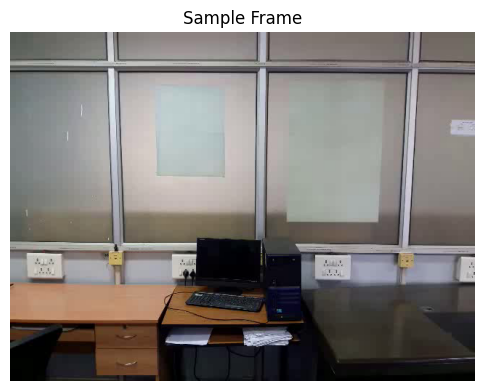

In [26]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Sample Frame")
plt.show()

In [27]:
def load_video(path, max_frames=16, resize=(112, 112)):
    cap = cv2.VideoCapture(str(path))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(0, total_frames - 1, max_frames).astype(int)
    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, resize)
        frame = frame.astype("float32") / 255.0

        frames.append(frame)

    cap.release()

    while len(frames) < max_frames:
        frames.append(np.zeros((resize[1], resize[0], 3), dtype="float32"))

    return np.array(frames)

In [28]:
video_tensor = load_video(sample_path)

print("Shape:", video_tensor.shape)
print("Min pixel value:", video_tensor.min())
print("Max pixel value:", video_tensor.max())

Shape: (16, 112, 112, 3)
Min pixel value: 0.0
Max pixel value: 0.9607843


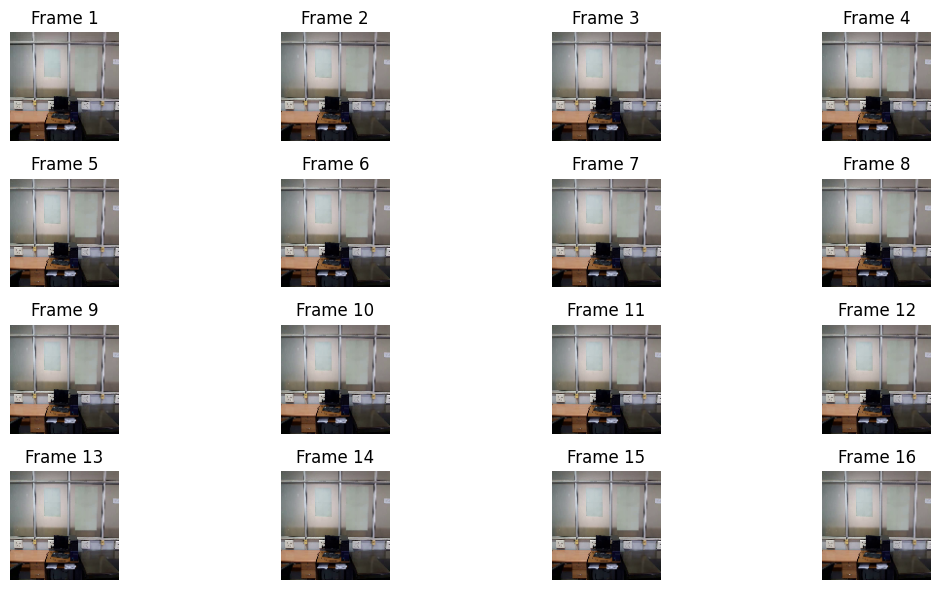

In [29]:
plt.figure(figsize=(12, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(video_tensor[i])
    plt.axis("off")
    plt.title(f"Frame {i+1}")

plt.tight_layout()
plt.show()

Sample path: /kaggle/input/shoplifting-video-dataset/shoplifting/shoplifting-93.mp4
Sample label: 1
Shape: (16, 112, 112, 3)
Min pixel value: 0.0
Max pixel value: 1.0


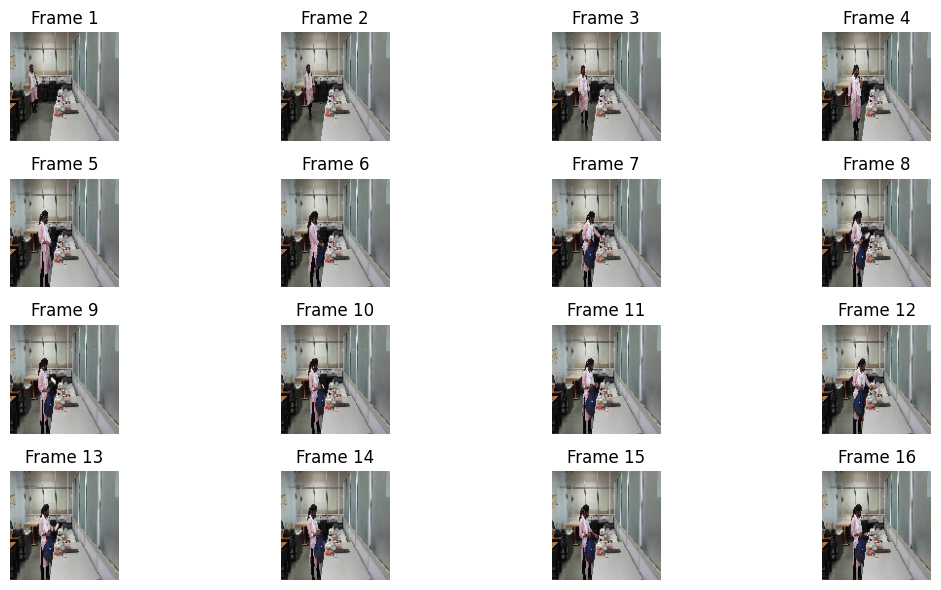

In [30]:
sample_path, sample_label = data[-1]

print("Sample path:", sample_path)
print("Sample label:", sample_label)

video_tensor = load_video(sample_path)

print("Shape:", video_tensor.shape)
print("Min pixel value:", video_tensor.min())
print("Max pixel value:", video_tensor.max())

plt.figure(figsize=(12, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(video_tensor[i])
    plt.axis("off")
    plt.title(f"Frame {i+1}")

plt.tight_layout()
plt.show()

In [31]:
X = []
y = []

for i, (path, label) in enumerate(data):
    video = load_video(path)

    if video is not None:
        X.append(video)
        y.append(label)

    if (i + 1) % 20 == 0:
        print(f"Processed {i + 1}/{len(data)} videos")

X = np.array(X, dtype="float32")
y = np.array(y, dtype="int32")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.bincount(y))

Processed 20/182 videos
Processed 40/182 videos
Processed 60/182 videos
Processed 80/182 videos
Processed 100/182 videos
Processed 120/182 videos
Processed 140/182 videos
Processed 160/182 videos
Processed 180/182 videos
X shape: (182, 16, 112, 112, 3)
y shape: (182,)
Labels: [90 92]


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train labels:", np.bincount(y_train))
print("y_test labels:", np.bincount(y_test))

X_train: (145, 16, 112, 112, 3)
X_test: (37, 16, 112, 112, 3)
y_train labels: [72 73]
y_test labels: [18 19]


In [33]:
model = models.Sequential([
    layers.Input(shape=(16, 112, 112, 3)),

    layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation="relu")),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation="relu")),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation="relu")),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.GlobalAveragePooling2D()),

    layers.LSTM(64),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 16, 110, 110,   │           896 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 55, 55, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 53, 53, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 16, 26, 26, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 16, 24, 24,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 12, 12,     │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 16, 128)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,881 (573.75 KB)

 Trainable params: 146,881 (573.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# history = model.fit(
#     X_train,
#     y_train,
#     validation_split=0.2,
#     epochs=15,
#     batch_size=4
# )

In [35]:
tf.keras.backend.clear_session()

In [36]:
base_cnn = tf.keras.applications.MobileNetV2(
    input_shape=(112, 112, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

base_cnn.trainable = False

/tmp/ipykernel_7125/695045157.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_cnn = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [37]:
X_train_mobilenet = X_train * 255.0
X_test_mobilenet = X_test * 255.0

X_train_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input(X_train_mobilenet)
X_test_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input(X_test_mobilenet)

print("Train min:", X_train_mobilenet.min())
print("Train max:", X_train_mobilenet.max())
print("Test min:", X_test_mobilenet.min())
print("Test max:", X_test_mobilenet.max())

Train min: -1.0
Train max: 1.0
Test min: -1.0
Test max: 1.0


In [38]:
inputs = layers.Input(shape=(16, 112, 112, 3))

x = layers.TimeDistributed(base_cnn)(inputs)

x = layers.LSTM(64)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

transfer_model = models.Model(inputs, outputs)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 112, 112,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,606,529 (9.94 MB)

 Trainable params: 348,545 (1.33 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [39]:
history_transfer = transfer_model.fit(
    X_train_mobilenet,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=4
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.5431 - loss: 0.7034 - precision: 0.5510 - recall: 0.4655 - val_accuracy: 0.5862 - val_loss: 0.6965 - val_precision: 0.5652 - val_recall: 0.8667
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 718ms/step - accuracy: 0.5948 - loss: 0.6418 - precision: 0.5821 - recall: 0.6724 - val_accuracy: 0.5517 - val_loss: 0.6728 - val_precision: 0.5714 - val_recall: 0.5333
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 761ms/step - accuracy: 0.6897 - loss: 0.5703 - precision: 0.7391 - recall: 0.5862 - val_accuracy: 0.5172 - val_loss: 0.6956 - val_precision: 0.5238 - val_recall: 0.7333
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 747ms/step - accuracy: 0.7586 - loss: 0.5305 - precision: 0.7273 - recall: 0.8276 - val_accuracy: 0.6897 - val_loss: 0.6427 - val_precision: 0.6500 - val_recall: 0.8667
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 779ms/step - accuracy: 0.8276 - loss: 0.4475 - precision: 0.8167 - recall: 0.8448 - val_accuracy: 0.6897 - val_loss:

In [40]:
test_loss, test_acc, test_precision, test_recall = transfer_model.evaluate(
    X_test_mobilenet,
    y_test
)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Test precision:", test_precision)
print("Test recall:", test_recall)

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8378 - loss: 0.4148 - precision: 0.8421 - recall: 0.8421
Test loss: 0.4148339331150055
Test accuracy: 0.837837815284729
Test precision: 0.8421052694320679
Test recall: 0.8421052694320679


In [41]:
from sklearn.metrics import confusion_matrix, classification_report

y_prob = transfer_model.predict(X_test_mobilenet).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)

print(classification_report(
    y_test,
    y_pred,
    target_names=["normal", "shoplifting"]
))

print("Min probability:", y_prob.min())
print("Max probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

2/2 ━━━━━━━━━━━━━━━━━━━━ 59s 22s/step
Confusion matrix:
[[15  3]
 [ 3 16]]
              precision    recall  f1-score   support

      normal       0.83      0.83      0.83        18
 shoplifting       0.84      0.84      0.84        19

    accuracy                           0.84        37
   macro avg       0.84      0.84      0.84        37
weighted avg       0.84      0.84      0.84        37

Min probability: 0.06326929
Max probability: 0.94680154
Mean probability: 0.5001941


In [42]:
wrong_indices = np.where(y_pred != y_test)[0]

print("Number of wrong predictions:", len(wrong_indices))
print("Wrong indices:", wrong_indices)

for idx in wrong_indices:
    print()
    print("Test index:", idx)
    print("True label:", y_test[idx])
    print("Pred label:", y_pred[idx])
    print("Shoplifting probability:", y_prob[idx])

Number of wrong predictions: 6
Wrong indices: [ 0 11 19 22 26 33]

Test index: 0
True label: 0
Pred label: 1
Shoplifting probability: 0.78017586

Test index: 11
True label: 1
Pred label: 0
Shoplifting probability: 0.25908127

Test index: 19
True label: 0
Pred label: 1
Shoplifting probability: 0.5255723

Test index: 22
True label: 0
Pred label: 1
Shoplifting probability: 0.77506024

Test index: 26
True label: 1
Pred label: 0
Shoplifting probability: 0.35417894

Test index: 33
True label: 1
Pred label: 0
Shoplifting probability: 0.15653765


In [43]:
def show_video_tensor(video_tensor, title="Video"):
    plt.figure(figsize=(12, 6))

    for i in range(video_tensor.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow((video_tensor[i] + 1) / 2 if video_tensor.min() < 0 else video_tensor[i])
        plt.axis("off")
        plt.title(f"F{i+1}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

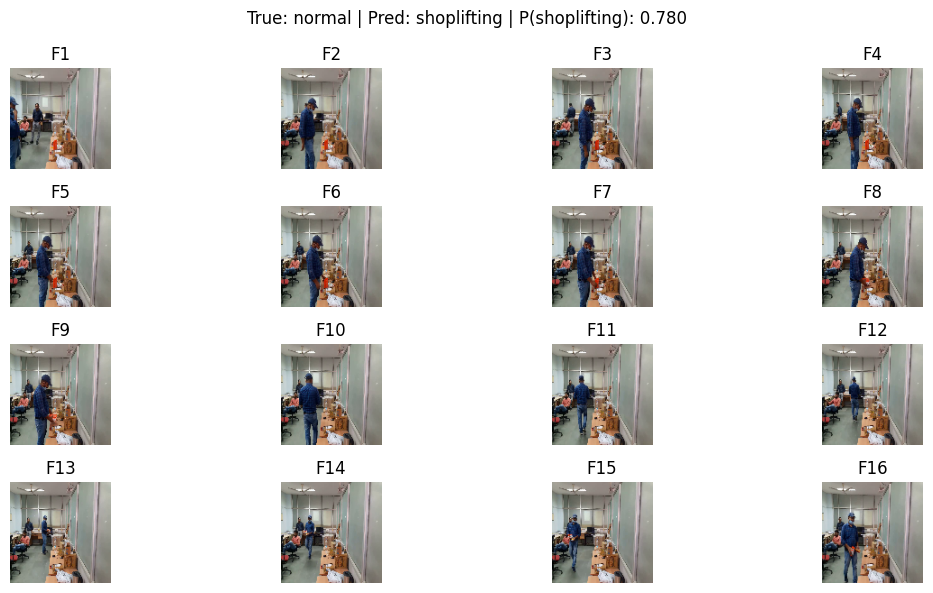

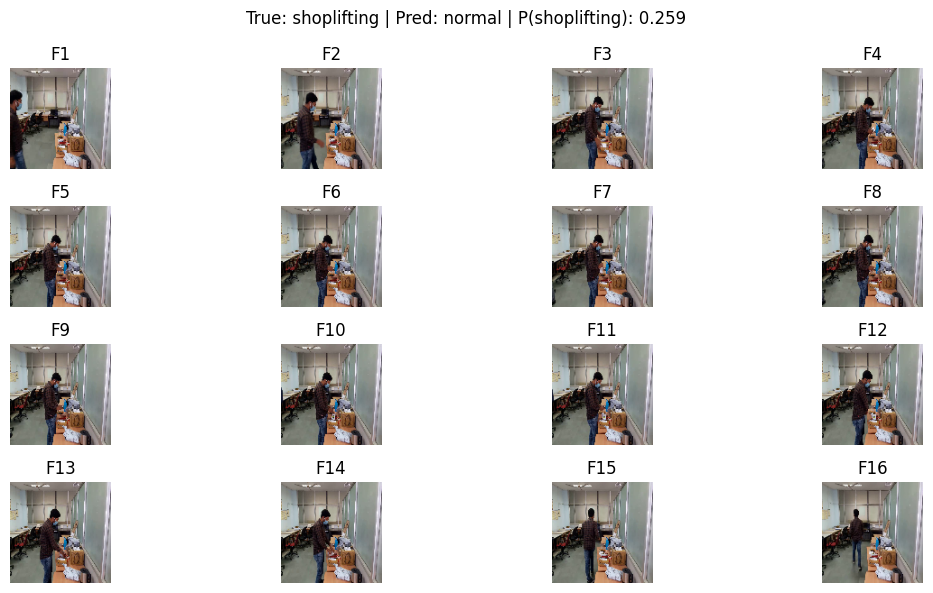

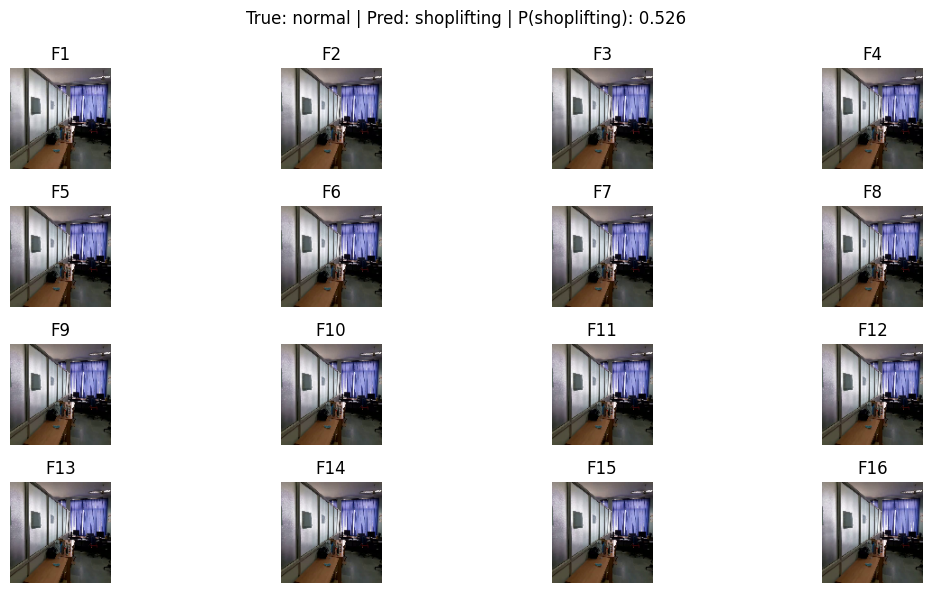

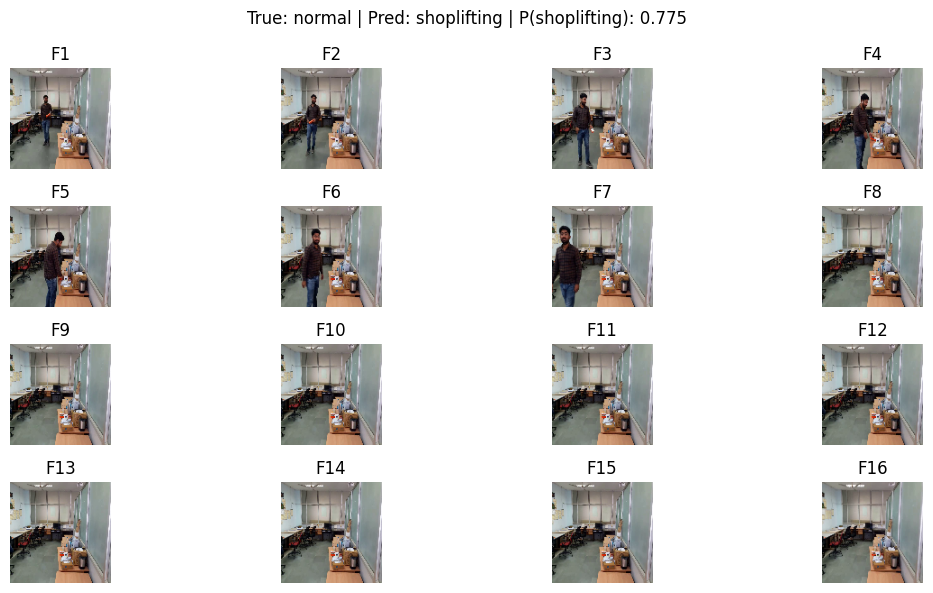

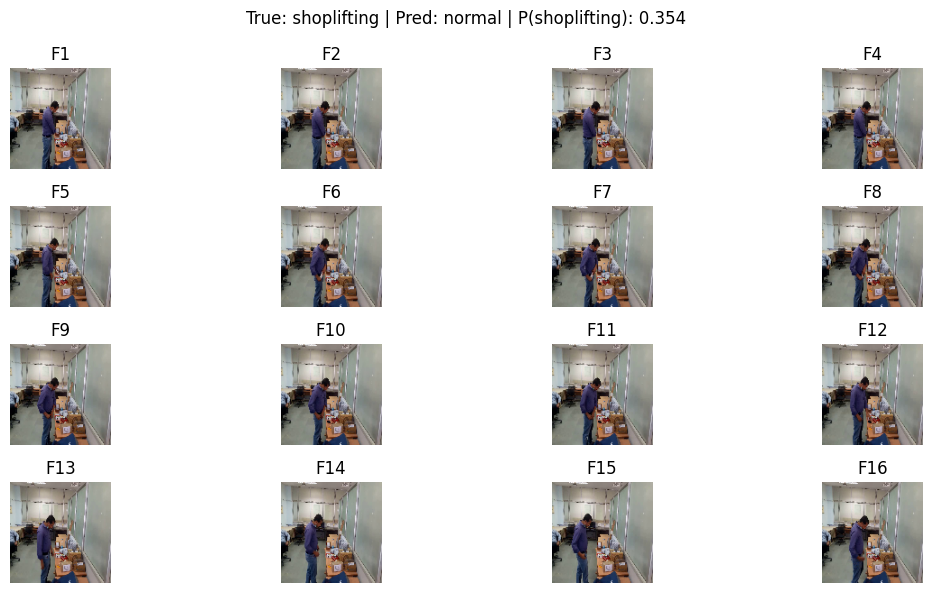

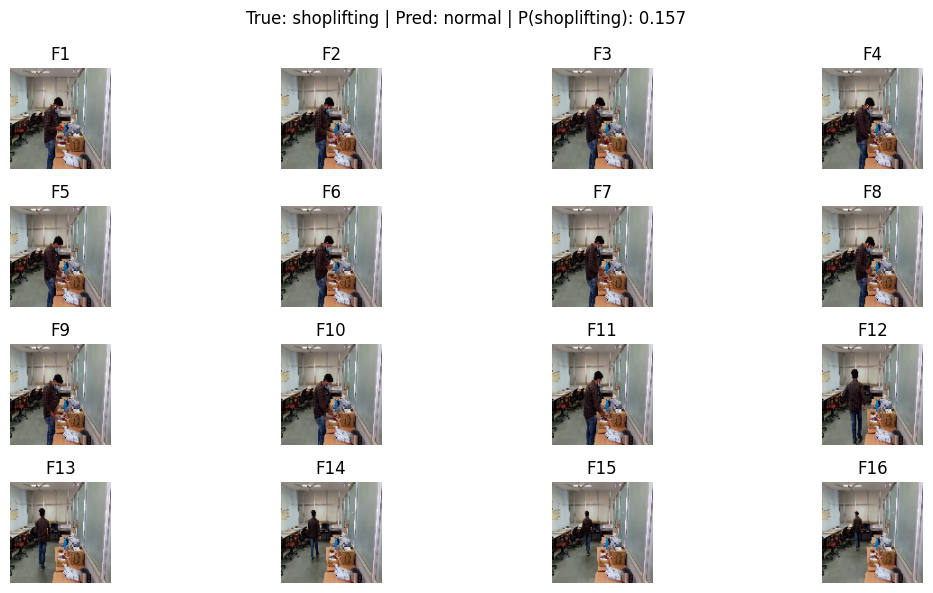

In [44]:
for idx in wrong_indices:
    true_label = "shoplifting" if y_test[idx] == 1 else "normal"
    pred_label = "shoplifting" if y_pred[idx] == 1 else "normal"

    title = f"True: {true_label} | Pred: {pred_label} | P(shoplifting): {y_prob[idx]:.3f}"

    show_video_tensor(X_test[idx], title=title)

In [46]:
with open('/content/sample_data/README.md', 'r') as f:
    readme_content = f.read()
print(readme_content)

This directory includes a few sample datasets to get you started.

*   `california_housing_data*.csv` is California housing data from the 1990 US
    Census; more information is available at:
    https://docs.google.com/document/d/e/2PACX-1vRhYtsvc5eOR2FWNCwaBiKL6suIOrxJig8LcSBbmCbyYsayia_DvPOOBlXZ4CAlQ5nlDD8kTaIDRwrN/pub

*   `mnist_*.csv` is a small sample of the
    [MNIST database](https://en.wikipedia.org/wiki/MNIST_database), which is
    described at: http://yann.lecun.com/exdb/mnist/

*   `anscombe.json` contains a copy of
    [Anscombe's quartet](https://en.wikipedia.org/wiki/Anscombe%27s_quartet); it
    was originally described in

    Anscombe, F. J. (1973). 'Graphs in Statistical Analysis'. American
    Statistician. 27 (1): 17-21. JSTOR 2682899.

    and our copy was prepared by the
    [vega_datasets library](https://github.com/altair-viz/vega_datasets/blob/4f67bdaad10f45e3549984e17e1b3088c731503d/vega_datasets/_data/anscombe.json).

